In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [70]:
from cycler import cycler
line_cycler   = (cycler(color=["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"]) +
                 cycler(linestyle=["-", "--", "-.", ":", "-", "--", "-."]))
marker_cycler = (cycler(color=["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"]) +
                 cycler(linestyle=["none", "none", "none", "none", "none", "none", "none"]) +
                 cycler(marker=["4", "2", "3", "1", "+", "x", "."]))

# Explanatory analysis of the tags

## pre-train

In [71]:
# load data
ptags = pd.read_csv('./data/pre-train_tags.csv',index_col=0)
pre_training_tags = ptags[ptags['agree'] == 1]


In [72]:
pre_training_tags['Cat'].value_counts()

Cat
c     388
do    173
di    164
l     124
t      50
u       2
Name: count, dtype: int64

<Axes: xlabel='Cat'>

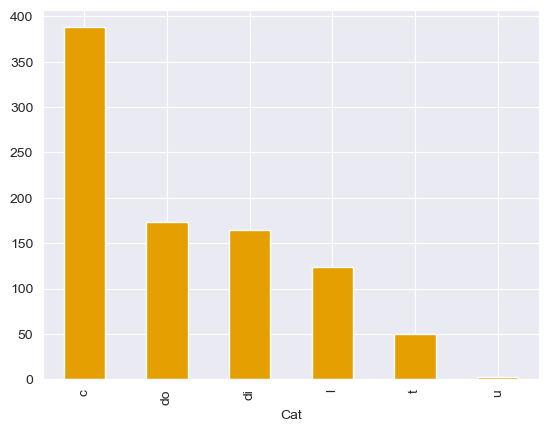

In [73]:
pre_training_tags['Cat'].value_counts().plot(kind='bar')

## Fine-tune


In [74]:
# load data
ftags = pd.read_csv('./data/fine-tune_tags.csv',index_col=0)
fine_tuning_tags = ftags[ftags['agree'] == 1]

In [75]:
fine_tuning_tags['Cat'].value_counts()

Cat
do    291
l     284
c     223
di    117
u       8
t       2
Name: count, dtype: int64

<Axes: xlabel='Cat'>

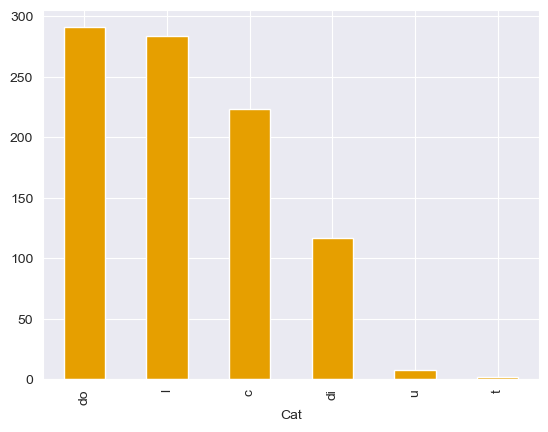

In [76]:
fine_tuning_tags['Cat'].value_counts().plot(kind='bar')

# Pre-training experiments

### Samples memorized per model size and categories - base model attack

tot tags pre train

In [17]:
tot_tags_pre = pre_training_tags[['bf16_ep0_p100_em', 'Cat']].groupby('Cat').count()
tot_tags_pre 
tot_tags_pre['bf16_ep0_p100_em']

Cat
c     388
di    164
do    173
l     124
t      50
u       2
Name: bf16_ep0_p100_em, dtype: int64

#### Heatmpap with absolute values

In [21]:
ep0_cat_fp32 = pre_training_tags[pre_training_tags['15b_ep0_p100_em'] == 1 ][['15b_ep0_p100_em', 'Cat']].groupby('Cat').count()
ep0_cat_bf16 = pre_training_tags[pre_training_tags['bf16_ep0_p100_em'] == 1 ][['bf16_ep0_p100_em', 'Cat']].groupby('Cat').count()
ep0_cat_i8 = pre_training_tags[pre_training_tags['i8_ep0_p100_em'] == 1 ][['i8_ep0_p100_em', 'Cat']].groupby('Cat').count()
ep0_cat_i4 = pre_training_tags[pre_training_tags['i4_ep0_p100_em'] == 1 ][['i4_ep0_p100_em', 'Cat']].groupby('Cat').count()


ep0_cat = ep0_cat_fp32.join(ep0_cat_bf16, lsuffix='_fp32', rsuffix='_bf16').join(ep0_cat_i4, rsuffix='_i4').join(ep0_cat_i8, rsuffix='_i8').loc[['c', 'di', 'do', 'l', 't']]

ep0_cat = ep0_cat.rename(columns={'15b_ep0_p100_em': 'fp32',
                                  'bf16_ep0_p100_em': 'bf16',
                                  'i8_ep0_p100_em': 'i8',
                                  'i4_ep0_p100_em': 'i4'})

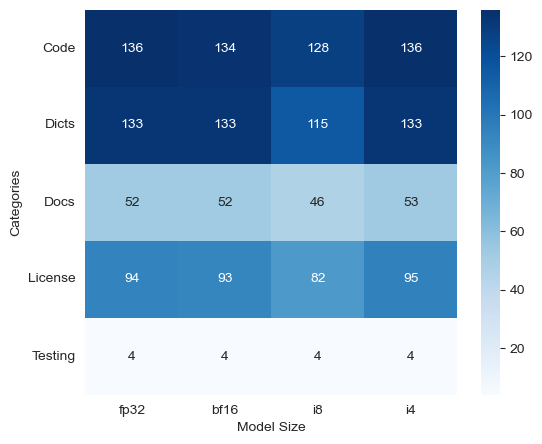

In [23]:
# Create the heatmap
plt.figure(figsize=(6, 5))  # Adjust the size as needed
ax = sns.heatmap(ep0_cat, annot=True, fmt='d', cmap='Blues', cbar=True)

# Set the title and labels
#ax.set_title('Heatmap with Annotations')
ax.set_ylabel('Categories')
ax.set_xlabel('Model Size')
ax.set_yticklabels(['Code', 'Dicts', 'Docs', 'License', 'Testing'], rotation=0)
ax.set_xticklabels(['fp32', 'bf16', 'i8', 'i4'], rotation=0)


# Show the plot
plt.show()

#### Barplot stacked

In [26]:
pre = tot_tags_pre['bf16_ep0_p100_em'].loc[['c', 'di', 'do', 'l', 't']]

In [28]:
ep0_cat['bf16']

Cat
c     134
di    133
do     52
l      93
t       4
Name: bf16, dtype: int64

#### With the percentages, compared to the total number of tags for each category

In [16]:
ep0_cat_3b = (pre_training_tags[pre_training_tags['3b_ep0_p100_em'] == 1 ][['3b_ep0_p100_em', 'Cat']].groupby('Cat').count() ) 
ep0_cat_7b = (pre_training_tags[pre_training_tags['7b_ep0_p100_em'] == 1 ][['7b_ep0_p100_em', 'Cat']].groupby('Cat').count() ) 
ep0_cat_15b = (pre_training_tags[pre_training_tags['15b_ep0_p100_em'] == 1 ][['15b_ep0_p100_em', 'Cat']].groupby('Cat').count()) 

ep0_cat_3b['3b_ep0_p100_em'] = ep0_cat_3b['3b_ep0_p100_em'] / tot_tags_pre['3b_ep0_p100_em'] * 100
ep0_cat_7b['7b_ep0_p100_em'] = ep0_cat_7b['7b_ep0_p100_em'] / tot_tags_pre['3b_ep0_p100_em'] * 100
ep0_cat_15b['15b_ep0_p100_em'] = ep0_cat_15b['15b_ep0_p100_em'] / tot_tags_pre['3b_ep0_p100_em'] * 100

ep0_cat_perc = ep0_cat_3b.join(ep0_cat_7b, lsuffix='_3b', rsuffix='_7b').join(ep0_cat_15b, rsuffix='_15b').loc[['c', 'di', 'do', 'l', 't']]
ep0_cat_perc = ep0_cat_perc.rename(columns={'3b_ep0_p100_em': '3b', '7b_ep0_p100_em': '7b', '15b_ep0_p100_em': '15b'})
ep0_cat_perc

,3b,7b,15b
Cat,,,
c,29.639175,30.154639,35.051546
di,75.609756,68.292683,81.097561
do,18.497110,24.277457,30.057803
l,68.548387,70.967742,75.806452
t,6.000000,6.000000,8.000000


In [40]:
ep0_cat_15b = (pre_training_tags[pre_training_tags['15b_ep0_p100_em'] == 1 ][['15b_ep0_p100_em', 'Cat']].groupby('Cat').count() )

ep0_cat_bf16 = (pre_training_tags[pre_training_tags['bf16_ep0_p100_em'] == 1 ][['bf16_ep0_p100_em', 'Cat']].groupby('Cat').count() )

ep0_cat_i8 = (pre_training_tags[pre_training_tags['i8_ep0_p100_em'] == 1 ][['i8_ep0_p100_em', 'Cat']].groupby('Cat').count() )

ep0_cat_i4 = (pre_training_tags[pre_training_tags['i4_ep0_p100_em'] == 1 ][['i4_ep0_p100_em', 'Cat']].groupby('Cat').count() )

ep0_cat_15b['15b_ep0_p100_em'] = ep0_cat_15b['15b_ep0_p100_em'] / tot_tags_pre['bf16_ep0_p100_em'] * 100

ep0_cat_bf16['bf16_ep0_p100_em'] = ep0_cat_bf16['bf16_ep0_p100_em'] / tot_tags_pre['bf16_ep0_p100_em'] * 100
ep0_cat_i8['i8_ep0_p100_em'] = ep0_cat_i8['i8_ep0_p100_em'] / tot_tags_pre['bf16_ep0_p100_em'] * 100
ep0_cat_i4['i4_ep0_p100_em'] = ep0_cat_i4['i4_ep0_p100_em'] / tot_tags_pre['bf16_ep0_p100_em'] * 100


ep0_cat_perc = ep0_cat_15b.join(ep0_cat_bf16, lsuffix='_fp32', rsuffix='_bf16').join(ep0_cat_i8, rsuffix='_i8').join(ep0_cat_i4, rsuffix='_i4').loc[['c', 'di', 'do', 'l', 't']]

ep0_cat_perc = ep0_cat_perc.rename(columns={'15b_ep0_p100_em': 'fp32',
                                  'bf16_ep0_p100_em': 'bf16',
                                  'i8_ep0_p100_em': 'i8',
                                  'i4_ep0_p100_em': 'i4'})
ep0_cat_perc

,fp32,bf16,i8,i4
Cat,,,,
c,35.051546,34.536082,35.051546,32.989691
di,81.097561,81.097561,81.097561,70.121951
do,30.057803,30.057803,30.635838,26.589595
l,75.806452,75.000000,76.612903,66.129032
t,8.000000,8.000000,8.000000,8.000000


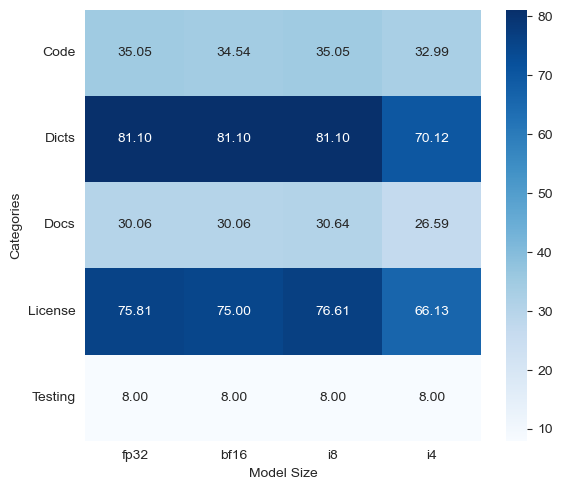

In [41]:
fig, ax = plt.subplots(figsize=(6, 5))  # Adjust the size as needed
# Create the heatmap
ax = sns.heatmap(ep0_cat_perc, annot=True, fmt='.2f', cmap='Blues', cbar=True)

# Set the title and labels
#ax.set_title('Heatmap with Annotations')
ax.set_ylabel('Categories')
ax.set_xlabel('Model Size')
ax.set_yticklabels(['Code', 'Dicts', 'Docs', 'License', 'Testing'], rotation=0)
ax.set_xticklabels(['fp32', 'bf16', 'i8', 'i4'], rotation=0)

# Adjust the layout to make sure everything fits
plt.tight_layout()


# Show the plot
plt.show()
fig.savefig('./tag_mem_ptrain_perc.pdf', format='pdf')

### Samples memorized per model size and categories - fine-tune model attack

#### Heatmap absolute values

In [77]:
ep3_cat_15b = pre_training_tags[pre_training_tags['15b_ep3_p100_em'] == 1 ][['15b_ep3_p100_em', 'Cat']].groupby('Cat').count()
ep3_cat_bf16 = pre_training_tags[pre_training_tags['bf16_ep3_p100_em'] == 1 ][['bf16_ep3_p100_em', 'Cat']].groupby('Cat').count()
ep3_cat_i8 = pre_training_tags[pre_training_tags['i8_ep3_p100_em'] == 1 ][['i8_ep3_p100_em', 'Cat']].groupby('Cat').count()
ep3_cat_i4 = pre_training_tags[pre_training_tags['i4_ep3_p100_em'] == 1 ][['i4_ep3_p100_em', 'Cat']].groupby('Cat').count()

ep3_cat = ep3_cat_15b.join(ep3_cat_bf16, lsuffix='_fp32', rsuffix='_bf16').join(ep3_cat_i8, rsuffix='_i8').join(ep3_cat_i4, rsuffix='_i4').loc[['c', 'di', 'do', 'l', 't']]
ep3_cat = ep3_cat.rename(columns={'15b_ep3_p100_em': 'fp32', 'bf16_ep3_p100_em': 'bf16', 'i8_ep3_p100_em': 'i8', 'i4_ep3_p100_em': 'i4'})

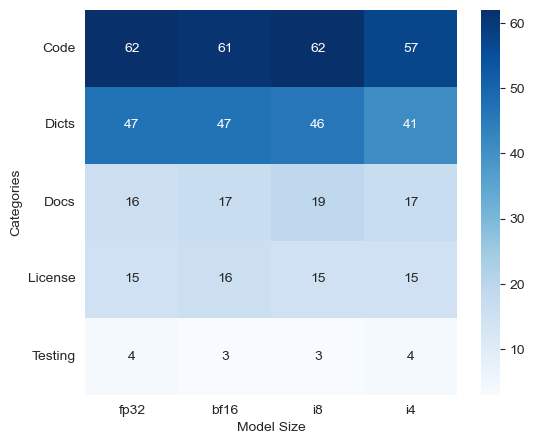

In [78]:
# Create the heatmap
plt.figure(figsize=(6, 5))  # Adjust the size as needed
ax = sns.heatmap(ep3_cat, annot=True, fmt='d', cmap='Blues', cbar=True)

# Set the title and labels
#ax.set_title('Heatmap with Annotations')
ax.set_ylabel('Categories')
ax.set_xlabel('Model Size')
ax.set_yticklabels(['Code', 'Dicts', 'Docs', 'License', 'Testing'], rotation=0)
ax.set_xticklabels(['fp32', 'bf16', 'i8', 'i4'], rotation=0)


# Show the plot
plt.show()

Percentage variation

In [79]:
((ep3_cat-ep0_cat)/ep0_cat)*100

,bf16,fp32,i4,i8
Cat,,,,
c,-54.477612,-54.411765,-55.468750,-54.411765
di,-64.661654,-64.661654,-64.347826,-65.413534
do,-67.307692,-69.230769,-63.043478,-64.150943
l,-82.795699,-84.042553,-81.707317,-84.210526
t,-25.000000,0.000000,0.000000,-25.000000


#### With the percentages, compared to the total number of tags for each category

In [80]:
ep3_cat_15b = pre_training_tags[pre_training_tags['15b_ep3_p100_em'] == 1 ][['15b_ep3_p100_em', 'Cat']].groupby('Cat').count()
ep3_cat_bf16 = pre_training_tags[pre_training_tags['bf16_ep3_p100_em'] == 1 ][['bf16_ep3_p100_em', 'Cat']].groupby('Cat').count()
ep3_cat_i8 = pre_training_tags[pre_training_tags['i8_ep3_p100_em'] == 1 ][['i8_ep3_p100_em', 'Cat']].groupby('Cat').count()
ep3_cat_i4 = pre_training_tags[pre_training_tags['i4_ep3_p100_em'] == 1 ][['i4_ep3_p100_em', 'Cat']].groupby('Cat').count()

ep3_cat_15b['15b_ep3_p100_em'] = ep3_cat_15b['15b_ep3_p100_em'] / tot_tags_pre['bf16_ep0_p100_em'] * 100
ep3_cat_bf16['bf16_ep3_p100_em'] = ep3_cat_bf16['bf16_ep3_p100_em'] / tot_tags_pre['bf16_ep0_p100_em'] * 100
ep3_cat_i8['i8_ep3_p100_em'] = ep3_cat_i8['i8_ep3_p100_em'] / tot_tags_pre['bf16_ep0_p100_em'] * 100
ep3_cat_i4['i4_ep3_p100_em'] = ep3_cat_i4['i4_ep3_p100_em'] / tot_tags_pre['bf16_ep0_p100_em'] * 100

ep3_cat_perc = ep3_cat_15b.join(ep3_cat_bf16, lsuffix='_fp32', rsuffix='_bf16').join(ep3_cat_i8, rsuffix='_i8').join(ep3_cat_i4, rsuffix='_i4').loc[['c', 'di', 'do', 'l', 't']]
ep3_cat_perc = ep3_cat_perc.rename(columns={'15b_ep3_p100_em': 'fp32', 'bf16_ep3_p100_em': 'bf16', 'i8_ep3_p100_em': 'i8', 'i4_ep3_p100_em': 'i4'})
ep3_cat_perc

,fp32,bf16,i8,i4
Cat,,,,
c,15.979381,15.721649,15.979381,14.690722
di,28.658537,28.658537,28.048780,25.000000
do,9.248555,9.826590,10.982659,9.826590
l,12.096774,12.903226,12.096774,12.096774
t,8.000000,6.000000,6.000000,8.000000


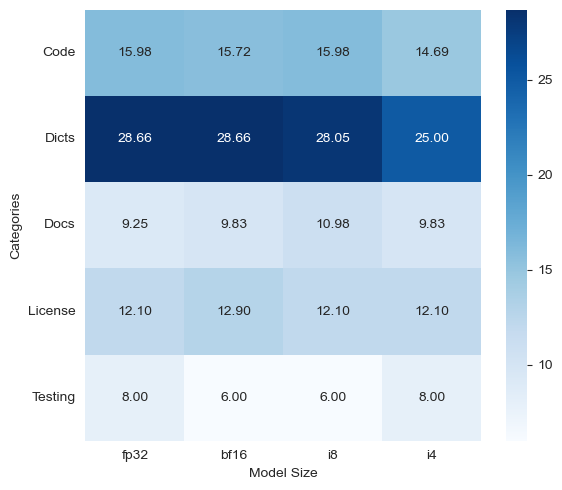

In [81]:
# Create the heatmap
plt.figure(figsize=(6, 5))  # Adjust the size as needed
ax = sns.heatmap(ep3_cat_perc, annot=True, fmt='.2f', cmap='Blues', cbar=True)

# Set the title and labels
#ax.set_title('Heatmap with Annotations')
ax.set_ylabel('Categories')
ax.set_xlabel('Model Size')
ax.set_yticklabels(['Code', 'Dicts', 'Docs', 'License', 'Testing'], rotation=0)
ax.set_xticklabels(['fp32', 'bf16', 'i8', 'i4'], rotation=0)


plt.tight_layout()
# Show the plot
plt.show()

## Put the percentages in one single plot:

In [82]:
ep0_cat_perc

,fp32,bf16,i8,i4
Cat,,,,
c,35.051546,34.536082,35.051546,32.989691
di,81.097561,81.097561,81.097561,70.121951
do,30.057803,30.057803,30.635838,26.589595
l,75.806452,75.000000,76.612903,66.129032
t,8.000000,8.000000,8.000000,8.000000


In [83]:
ep3_cat_perc

,fp32,bf16,i8,i4
Cat,,,,
c,15.979381,15.721649,15.979381,14.690722
di,28.658537,28.658537,28.048780,25.000000
do,9.248555,9.826590,10.982659,9.826590
l,12.096774,12.903226,12.096774,12.096774
t,8.000000,6.000000,6.000000,8.000000


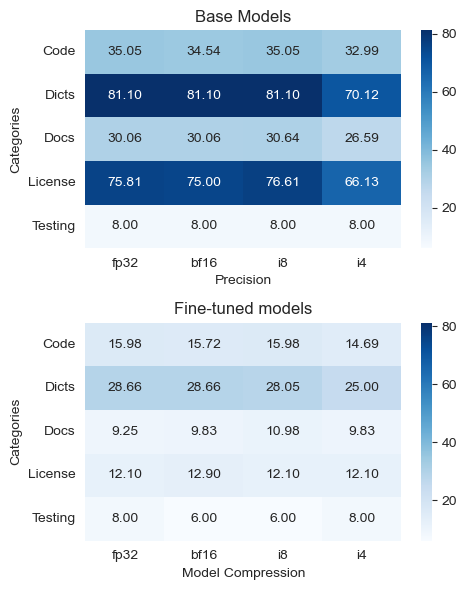

In [84]:
# Use the precision-level data (from cells 24 and 33)
ep0_cat_perc_prec = ep0_cat_perc  # This is already the precision-level data from cell 24
ep3_cat_perc_prec = ep3_cat_perc  # This is already the precision-level data from cell 33

# Determine the global min and max values for the color scale
vmin = min(ep0_cat_perc_prec.min().min(), ep3_cat_perc_prec.min().min())
vmax = max(ep0_cat_perc_prec.max().max(), ep3_cat_perc_prec.max().max())

# Create subplots with a vertical stack
fig, axes = plt.subplots(2, 1, figsize=(5, 6))  # Adjust figsize for vertical layout

# Plot the first heatmap
sns.heatmap(ep0_cat_perc_prec, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax=axes[0], vmin=vmin, vmax=vmax)
axes[0].set_title('Base Models')
axes[0].set_ylabel('Categories')
axes[0].set_xlabel('Precision')
axes[0].set_yticklabels(['Code', 'Dicts', 'Docs', 'License', 'Testing'], rotation=0)
axes[0].set_xticklabels(['fp32', 'bf16', 'i8', 'i4'], rotation=0)

# Plot the second heatmap
sns.heatmap(ep3_cat_perc_prec, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax=axes[1], vmin=vmin, vmax=vmax)
axes[1].set_title('Fine-tuned models')
axes[1].set_ylabel('Categories')
axes[1].set_xlabel('Model Compression')
axes[1].set_yticklabels(['Code', 'Dicts', 'Docs', 'License', 'Testing'], rotation=0)
axes[1].set_xticklabels(['fp32', 'bf16', 'i8', 'i4'], rotation=0)

plt.tight_layout()
# Save the plot as a PDF
plt.savefig('./quant_attack_mem_prec.pdf', format='pdf')
# Show the plot
plt.show()

Total tags fine-tuning samples

In [85]:
fine_tuning_tags.columns

Index(['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
       'bf16_ep0_d3', 'bf16_ep0_d3_em', 'bf16_ep0_d3_bleu',
       'bf16_ep0_d3_meteor', 'bf16_ep0_d3_rougeL', 'bf16_ep3_d3',
       'bf16_ep3_d3_em', 'bf16_ep3_d3_bleu', 'bf16_ep3_d3_meteor',
       'bf16_ep3_d3_rougeL', 'i8_ep0_d3', 'i8_ep0_d3_em', 'i8_ep0_d3_bleu',
       'i8_ep0_d3_meteor', 'i8_ep0_d3_rougeL', 'i8_ep3_d3', 'i8_ep3_d3_em',
       'i8_ep3_d3_bleu', 'i8_ep3_d3_meteor', 'i8_ep3_d3_rougeL', 'i4_ep0_d3',
       'i4_ep0_d3_em', 'i4_ep0_d3_bleu', 'i4_ep0_d3_meteor',
       'i4_ep0_d3_rougeL', 'i4_ep3_d3', 'i4_ep3_d3_em', 'i4_ep3_d3_bleu',
       'i4_ep3_d3_meteor', 'i4_ep3_d3_rougeL', '15b_ep0_d3', '15b_ep0_d3_em',
       '15b_ep0_d3_bleu', '15b_ep0_d3_meteor', '15b_ep0_d3_rougeL',
       '15b_ep3_d3', '15b_ep3_d3_em', '15b_ep3_d3_bleu', '15b_ep3_d3_meteor',
       '15b_ep3_d3_rougeL', 'eval_sample', 'Cat', 'Interesting', 'agree'],
      dtype='object')

In [86]:
tot_tags_tune = fine_tuning_tags[['15b_ep0_d3_em', 'Cat']].groupby('Cat').count()
tot_tags_tune

,15b_ep0_d3_em
Cat,
c,223
di,117
do,291
l,284
t,2
u,8


### Absolute values

In [87]:
ep3_cat_15b = fine_tuning_tags[fine_tuning_tags['15b_ep3_d3_em'] == 1 ][['15b_ep3_d3_em', 'Cat']].groupby('Cat').count()
ep3_cat_bf16 = fine_tuning_tags[fine_tuning_tags['bf16_ep3_d3_em'] == 1 ][['bf16_ep3_d3_em', 'Cat']].groupby('Cat').count()
ep3_cat_i8 = fine_tuning_tags[fine_tuning_tags['i8_ep3_d3_em'] == 1 ][['i8_ep3_d3_em', 'Cat']].groupby('Cat').count()
ep3_cat_i4 = fine_tuning_tags[fine_tuning_tags['i4_ep3_d3_em'] == 1 ][['i4_ep3_d3_em', 'Cat']].groupby('Cat').count()

ep3_cat = ep3_cat_15b.join(ep3_cat_bf16, lsuffix='_fp32', rsuffix='_bf16').join(ep3_cat_i8, rsuffix='_i8').join(ep3_cat_i4, rsuffix='_i4').loc[['c', 'di', 'do', 'l', 't']]
ep3_cat = ep3_cat.rename(columns={'15b_ep3_d3_em': 'fp32', 'bf16_ep3_d3_em': 'bf16', 'i8_ep3_d3_em': 'i8', 'i4_ep3_d3_em': 'i4'})
ep3_cat

,fp32,bf16,i8,i4
Cat,,,,
c,88,87,89,77
di,64,65,63,67
do,137,137,136,117
l,195,196,196,192
t,1,1,1,1


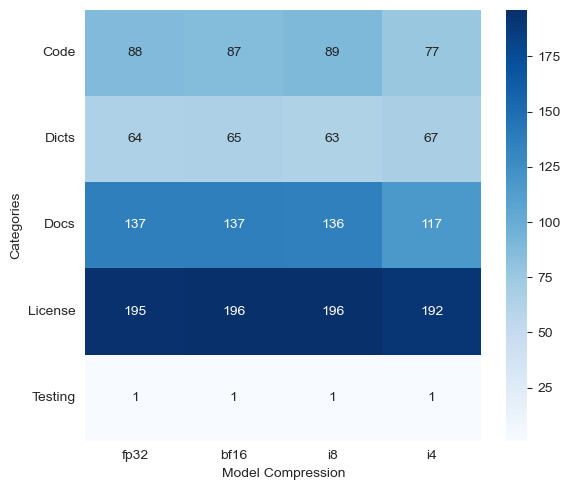

In [88]:
# Create the heatmap
fig, ax = plt.subplots(figsize=(6, 5))  # Adjust the size as needed
ax = sns.heatmap(ep3_cat, annot=True, fmt='d', cmap='Blues', cbar=True)

# Set the title and labels
#ax.set_title('Heatmap with Annotations')
ax.set_ylabel('Categories')
ax.set_xlabel('Model Compression')
ax.set_yticklabels(['Code', 'Dicts', 'Docs', 'License', 'Testing'], rotation=0)
axes[1].set_xticklabels(['fp32', 'bf16', 'i8', 'i4'], rotation=0)

fig.tight_layout()
# Show the plot
plt.show()

### With the percentages, compared to the total number of tags for each category

In [89]:
ep3_cat_15b = fine_tuning_tags[fine_tuning_tags['15b_ep3_d3_em'] == 1 ][['15b_ep3_d3_em', 'Cat']].groupby('Cat').count()
ep3_cat_bf16 = fine_tuning_tags[fine_tuning_tags['bf16_ep3_d3_em'] == 1 ][['bf16_ep3_d3_em', 'Cat']].groupby('Cat').count()
ep3_cat_i8 = fine_tuning_tags[fine_tuning_tags['i8_ep3_d3_em'] == 1 ][['i8_ep3_d3_em', 'Cat']].groupby('Cat').count()
ep3_cat_i4 = fine_tuning_tags[fine_tuning_tags['i4_ep3_d3_em'] == 1 ][['i4_ep3_d3_em', 'Cat']].groupby('Cat').count()

ep3_cat_15b['15b_ep3_d3_em'] = ep3_cat_15b['15b_ep3_d3_em'] / tot_tags_tune['15b_ep0_d3_em'] * 100
ep3_cat_bf16['bf16_ep3_d3_em'] = ep3_cat_bf16['bf16_ep3_d3_em'] / tot_tags_tune['15b_ep0_d3_em'] * 100
ep3_cat_i8['i8_ep3_d3_em'] = ep3_cat_i8['i8_ep3_d3_em'] / tot_tags_tune['15b_ep0_d3_em'] * 100
ep3_cat_i4['i4_ep3_d3_em'] = ep3_cat_i4['i4_ep3_d3_em'] / tot_tags_tune['15b_ep0_d3_em'] * 100

ep3_cat = ep3_cat_15b.join(ep3_cat_bf16, lsuffix='_fp32', rsuffix='_bf16').join(ep3_cat_i8, rsuffix='_i8').join(ep3_cat_i4, rsuffix='_i4').loc[['c', 'di', 'do', 'l', 't']]
ep3_cat = ep3_cat.rename(columns={'15b_ep3_d3_em': 'fp32', 'bf16_ep3_d3_em': 'bf16', 'i8_ep3_d3_em': 'i8', 'i4_ep3_d3_em': 'i4'})

ep3_cat

,fp32,bf16,i8,i4
Cat,,,,
c,39.461883,39.013453,39.910314,34.529148
di,54.700855,55.555556,53.846154,57.264957
do,47.079038,47.079038,46.735395,40.206186
l,68.661972,69.014085,69.014085,67.605634
t,50.000000,50.000000,50.000000,50.000000


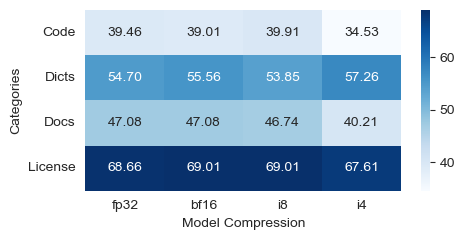

In [90]:
# Create the heatmap
fig, ax = plt.subplots(figsize=(5, 2.5))  # Adjust the size as needed
ax = sns.heatmap(ep3_cat.loc[['c', 'di', 'do', 'l']], annot=True, fmt='.2f', cmap='Blues', cbar=True)

# Set the title and labels
#ax.set_title('Heatmap with Annotations')
ax.set_ylabel('Categories')
ax.set_xlabel('Model Compression')
ax.set_yticklabels(['Code', 'Dicts', 'Docs', 'License'], rotation=0)
axes[1].set_xticklabels(['fp32', 'bf16', 'i8', 'i4'], rotation=0)

fig.tight_layout()
# Show the plot
plt.show()
fig.savefig('./tag_mem_ftune_perc.pdf', format='pdf')